LECTURA DE DATASETS

In [ ]:
import pandas as pd

def procesar_cuestionario(filepath):
    # Leer el Excel completo sin encabezados automáticos
    df = pd.read_excel(filepath, header=None)

    # Extraer las filas según la estructura correcta del Excel:
    # Fila 1 (índice 0): Tipo (Expectativa / Percepción)
    # Fila 3 (índice 2): ID del ítem (1, 2, 3...)
    # Fila 4 (índice 3): Texto del ítem (La pregunta en sí)
    fila_tipo = df.iloc[0, :].astype(str).str.lower()
    fila_dimension = df.iloc[1, :].astype(str).str.lower()
    fila_id = df.iloc[2, :].astype(str).str.replace(".0", "", regex=False) # Por si pandas los lee como decimales
    fila_texto = df.iloc[3, :].astype(str)

    cols_expectativas = []
    cols_percepcion = []

    encabezados_expectativas = []
    encabezados_percepcion = []

    contador_pares = 1

    # Recorrer columnas para identificar categorías (los datos del cuestionario empiezan en col G)
    for i in range(len(df.columns)):
        tipo = fila_tipo[i].strip()

        if 'expectativa' in tipo:
            cols_expectativas.append(i)
            encabezados_expectativas.append((contador_pares, fila_texto[i], fila_id[i]))

        elif 'percepcion' in tipo or 'percepción' in tipo:
            cols_percepcion.append(i)
            encabezados_percepcion.append((contador_pares, fila_texto[i], fila_id[i]))
            contador_pares += 1

    # Extraer ÚNICAMENTE los datos de las respuestas (a partir de la fila 5 del Excel -> índice 4)
    df_respuestas = df.iloc[4:, :].reset_index(drop=True)

    # Construir datasets numéricos usando el ID como nombre de columna
    df_exp = df_respuestas[cols_expectativas].apply(pd.to_numeric, errors='coerce')
    df_exp.columns = [item[2] for item in encabezados_expectativas]

    df_perc = df_respuestas[cols_percepcion].apply(pd.to_numeric, errors='coerce')
    df_perc.columns = [item[2] for item in encabezados_percepcion]

    # 1. Imprimir los encabezados con su número, texto completo e ID
    print(f"=== DATASET DE EXPECTATIVAS ({len(encabezados_expectativas)} Ítems) ===")
    for num, texto, item_id in encabezados_expectativas:
        print(f"{num:02d}. [ID: {item_id}] {texto}")

    print(f"\n=== DATASET DE PERCEPCIÓN ({len(encabezados_percepcion)} Ítems) ===")
    for num, texto, item_id in encabezados_percepcion:
        print(f"{num:02d}. [ID: {item_id}] {texto}")

    # 2. Imprimir la cantidad correcta de respuestas obtenidas
    print("\n=== RESUMEN DE RESPUESTAS ===")
    print(f"Cantidad de respuestas procesadas en Expectativas: {len(df_exp)}")
    print(f"Cantidad de respuestas procesadas en Percepción: {len(df_perc)}")

    return df_exp, df_perc

# Ejecución
archivo = 'Respuestas_expectativas_vs_percepcion.xlsx'
df_expectativas, df_percepcion = procesar_cuestionario(archivo)

=== DATASET DE EXPECTATIVAS (41 Ítems) ===
01. [ID: 1] Debería sentirme completamente concentrado/a en una actividad educativa mientras uso RV.
02. [ID: 3] La actividad en RV debería hacerme perder la noción del tiempo por lo inmersiva que es.
03. [ID: 5] Debería sentirme en total control de mis acciones en el entorno virtual.
04. [ID: 7] Mis acciones deberían tener el efecto deseado en el entorno virtual.
05. [ID: 9] El sistema de RV debería responder adecuadamente a mis movimientos o comandos.
06. [ID: 11] La RV con un avatar de IA debería ayudarme a comprender mejor los contenidos.
07. [ID: 13] Un avatar de IA en RV debería ser mejor que una clase tradicional.
08. [ID: 15] Debería aprender más rápido utilizando un avatar de IA en RV.
09. [ID: 17] Debería comprender los temas más rápidamente con ayuda del avatar de IA en RV.
10. [ID: 19] Los avatares virtuales con IA deberían contribuir significativamente a mi aprendizaje.
11. [ID: 21] Debería sentirme cómodo/a físicamente al usar el

TEST DE NORMALIDAD CON SHAPIRO WILK

In [ ]:
import pandas as pd
from scipy.stats import shapiro

def evaluar_normalidad_dataset(df, nombre_dataset, alfa=0.05):
    """
    Evalúa la normalidad de cada ítem en un DataFrame usando Shapiro-Wilk.
    """
    items_normales = 0
    items_no_normales = 0

    print(f"\n=== ANÁLISIS DE NORMALIDAD: {nombre_dataset.upper()} ===")

    for columna in df.columns:
        # Extraer los datos del ítem, omitiendo valores nulos para no romper el test
        datos_item = df[columna].dropna()

        # Shapiro-Wilk requiere al menos 3 datos
        if len(datos_item) >= 3:
            estadistico, p_valor = shapiro(datos_item)

            if p_valor < alfa:
                # p-valor < 0.05: Se rechaza la hipótesis nula (NO es normal)
                items_no_normales += 1
            else:
                # p-valor >= 0.05: No se rechaza la hipótesis nula (ES normal)
                items_normales += 1
        else:
            print(f"Ítem {columna} omitido: datos insuficientes.")

    total_items = items_normales + items_no_normales

    # Imprimir resumen de resultados
    print(f"Total de ítems analizados: {total_items}")
    print(f"Ítems con distribución NORMAL (p >= {alfa}): {items_normales}")
    print(f"Ítems con distribución NO NORMAL (p < {alfa}): {items_no_normales}")

    # Conclusión general
    if items_normales == total_items:
        print(f"-> CONCLUSIÓN: El dataset '{nombre_dataset}' tiene una distribución NORMAL en su totalidad.")
    elif items_normales == 0:
        print(f"-> CONCLUSIÓN: El dataset '{nombre_dataset}' tiene una distribución NO NORMAL en su totalidad.")
    else:
        print(f"-> CONCLUSIÓN: El dataset '{nombre_dataset}' es MIXTO ({items_normales} normales, {items_no_normales} no normales).")

    return items_normales, items_no_normales

# --- EJECUCIÓN DEL ANÁLISIS ---
# (Asumiendo que df_expectativas y df_percepcion vienen de tu código anterior)

evaluar_normalidad_dataset(df_expectativas, "Expectativas", alfa=0.05)
evaluar_normalidad_dataset(df_percepcion, "Percepción", alfa=0.05)


=== ANÁLISIS DE NORMALIDAD: EXPECTATIVAS ===
Total de ítems analizados: 41
Ítems con distribución NORMAL (p >= 0.05): 0
Ítems con distribución NO NORMAL (p < 0.05): 41
-> CONCLUSIÓN: El dataset 'Expectativas' tiene una distribución NO NORMAL en su totalidad.

=== ANÁLISIS DE NORMALIDAD: PERCEPCIÓN ===
Total de ítems analizados: 41
Ítems con distribución NORMAL (p >= 0.05): 0
Ítems con distribución NO NORMAL (p < 0.05): 41
-> CONCLUSIÓN: El dataset 'Percepción' tiene una distribución NO NORMAL en su totalidad.


(0, 41)

DISTRIBUCIONES NO NORMALES -> TEST DE WILCOXON PARA HALLAR DIFERENCIAS SIGNIFICATIVAS ENTRE EXPECTATIVAS VS PERCEPCION

In [ ]:
import pandas as pd
from scipy.stats import wilcoxon
import warnings

def prueba_wilcoxon_items(filepath):
    # Omitir warnings si algún ítem tiene diferencias idénticas a cero que afecten el cálculo exacto de scipy
    warnings.filterwarnings("ignore")

    # 1. Cargar el Excel completo
    df = pd.read_excel(filepath, header=None)

    # 2. Extraer metadatos
    fila_tipo = df.iloc[0, :].astype(str).str.lower()
    fila_id = df.iloc[2, :].astype(str).str.replace(".0", "", regex=False)

    cols_expectativas = []
    cols_percepcion = []

    # Recorrer columnas para identificar las categorías
    for i in range(len(df.columns)):
        tipo = fila_tipo[i].strip()
        if 'expectativa' in tipo:
            cols_expectativas.append(i)
        elif 'percepcion' in tipo or 'percepción' in tipo:
            cols_percepcion.append(i)

    # 3. Extraer solo las respuestas numéricas (desde la fila 5)
    df_respuestas = df.iloc[4:, :].reset_index(drop=True)
    df_exp = df_respuestas[cols_expectativas].apply(pd.to_numeric, errors='coerce')
    df_perc = df_respuestas[cols_percepcion].apply(pd.to_numeric, errors='coerce')

    resultados = []

    # 4. Análisis Ítem por Ítem
    print(f"{'ÍTEM':<6} | {'P-VALOR':<8} | {'α = 0.05':<12} | {'α = 0.01':<12} | {'α = 0.001':<12}")
    print("-" * 65)

    for i in range(len(cols_expectativas)):
        # Extraer la columna de expectativa y su par de percepción
        col_exp = df_exp.iloc[:, i]
        col_perc = df_perc.iloc[:, i]

        # Unir ambas columnas y eliminar filas con NAs para asegurar que las muestras estén perfectamente emparejadas
        pares = pd.concat([col_exp, col_perc], axis=1).dropna()

        if len(pares) >= 3:
            # Calcular Wilcoxon Signed-Rank Test
            stat, p_valor = wilcoxon(pares.iloc[:, 0], pares.iloc[:, 1])

            # Evaluar Hipótesis Alternativa (H1: Existe diferencia significativa)
            # Si p_valor < alpha, se Confirma H1. Si p_valor >= alpha, se Rechaza H1 (Se mantiene H0).
            res_05 = "Confirma" if p_valor < 0.05 else "Rechaza"
            res_01 = "Confirma" if p_valor < 0.01 else "Rechaza"
            res_001 = "Confirma" if p_valor < 0.001 else "Rechaza"

            numero_item = f"[{i+1:02d}]"
            p_str = f"{p_valor:.4f}"

            # Imprimir fila tabulada por pantalla
            print(f"{numero_item:<6} | {p_str:<8} | {res_05:<12} | {res_01:<12} | {res_001:<12}")

            # Guardar en diccionario por si se desea exportar después a un nuevo Excel
            resultados.append({
                "Ítem": i+1,
                "p-valor": p_valor,
                "Alfa 0.05": res_05,
                "Alfa 0.01": res_01,
                "Alfa 0.001": res_001
            })
        else:
            print(f"[{i+1:02d}]    | OMITIDO  | Datos insuficientes para el test")

    # Retorna el DataFrame en caso de que lo necesites para guardarlo en un CSV/Excel posteriormente
    return pd.DataFrame(resultados)

# Ejecutar la función
df_resultados_wilcoxon = prueba_wilcoxon_items('Respuestas_expectativas_vs_percepcion.xlsx')

ÍTEM   | P-VALOR  | α = 0.05     | α = 0.01     | α = 0.001   
-----------------------------------------------------------------
[01]   | 0.4137   | Rechaza      | Rechaza      | Rechaza     
[02]   | 0.5613   | Rechaza      | Rechaza      | Rechaza     
[03]   | 0.1410   | Rechaza      | Rechaza      | Rechaza     
[04]   | 0.6726   | Rechaza      | Rechaza      | Rechaza     
[05]   | 0.2232   | Rechaza      | Rechaza      | Rechaza     
[06]   | 0.3063   | Rechaza      | Rechaza      | Rechaza     
[07]   | 0.3194   | Rechaza      | Rechaza      | Rechaza     
[08]   | 0.9873   | Rechaza      | Rechaza      | Rechaza     
[09]   | 0.7145   | Rechaza      | Rechaza      | Rechaza     
[10]   | 0.0565   | Rechaza      | Rechaza      | Rechaza     
[11]   | 0.8693   | Rechaza      | Rechaza      | Rechaza     
[12]   | 0.6720   | Rechaza      | Rechaza      | Rechaza     
[13]   | 0.0000   | Confirma     | Confirma     | Confirma    
[14]   | 0.0388   | Confirma     | Rechaza      | Re

SPIDERCHART

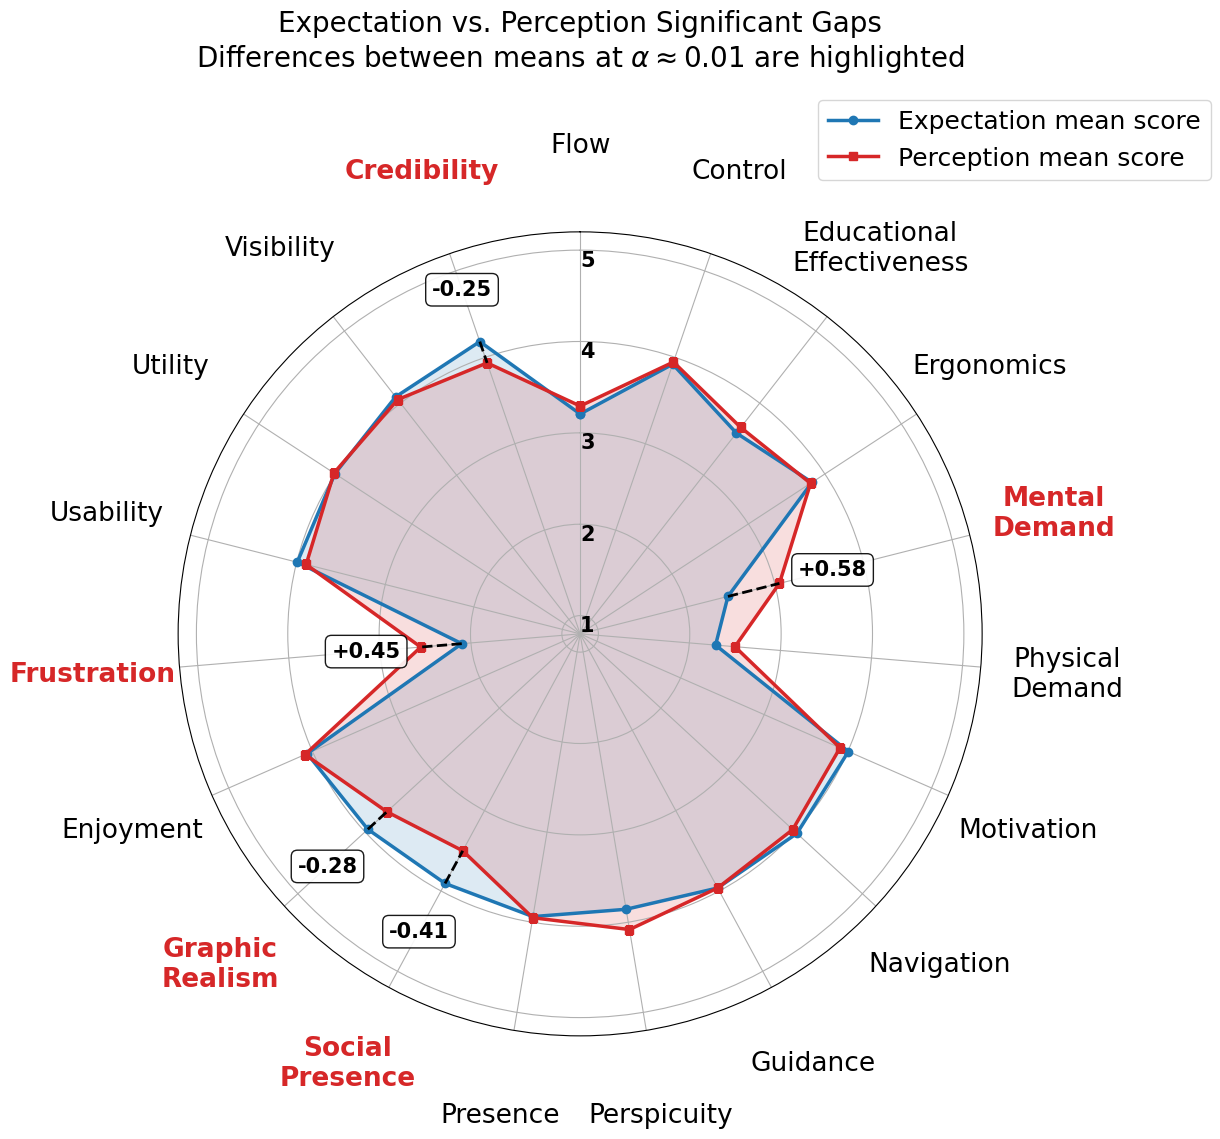

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import warnings

def generate_english_spiderchart(file_path):
    warnings.filterwarnings('ignore')

    # 1. Cargar el dataset
    df = pd.read_excel(file_path, header=None)
    fila_tipo = df.iloc[0, 6:].astype(str).str.lower()
    fila_dim = df.iloc[1, 6:].astype(str)

    # Extraer las respuestas numéricas
    df_resp = df.iloc[4:, 6:].apply(pd.to_numeric, errors='coerce').reset_index(drop=True)

    # 2. Diccionario de Traducción Actualizado (19 Dimensiones)
    translation_dict = {
        'Concentración absoluta': 'Flow',
        'Control': 'Control',
        'Efectividad educativa': 'Educational Effectiveness',
        'Ergonomía': 'Ergonomics',
        'Esfuerzo cognitivo': 'Mental Demand',
        'Esfuerzo físico': 'Physical Demand',
        'Motivación': 'Motivation',
        'Navegación': 'Navigation',
        'Orientación': 'Guidance',
        'Perspicuidad': 'Perspicuity',
        'Presencia': 'Presence',
        'Presencia social': 'Social Presence',
        'Realismo gráfico': 'Graphic Realism',
        'Disfrute': 'Enjoyment',
        'Enjoyment': 'Enjoyment',
        'Frustración': 'Frustration',
        'Frustration': 'Frustration',
        'Usabilidad': 'Usability',
        'Utilidad': 'Utility',
        'Visibilidad': 'Visibility',
        'Credibilidad': 'Credibility'
    }

    # --- FILTRO: Dimensiones exclusivas a destacar ---
    target_dimensions = [
        'Frustration',
        'Credibility',
        'Mental Demand',
        'Social Presence',
        'Graphic Realism'
    ]

    dimensiones_unicas = fila_dim.unique()

    media_exp_list = []
    media_perc_list = []
    p_val_list = []

    # 3. Procesamiento estadístico
    for dim in dimensiones_unicas:
        idx_dim = [i for i, d in enumerate(fila_dim) if d == dim]
        cols_exp = [i for i in idx_dim if 'expectativa' in fila_tipo.iloc[i]]
        cols_perc = [i for i in idx_dim if 'percepcion' in fila_tipo.iloc[i] or 'percepción' in fila_tipo.iloc[i]]

        # Promedio intrapersonal
        exp_scores = df_resp.iloc[:, cols_exp].mean(axis=1)
        perc_scores = df_resp.iloc[:, cols_perc].mean(axis=1)

        pares = pd.concat([exp_scores, perc_scores], axis=1).dropna()

        media_exp_list.append(pares.iloc[:, 0].mean())
        media_perc_list.append(pares.iloc[:, 1].mean())

        # Test de Wilcoxon
        if len(pares) >= 3:
            stat, p = wilcoxon(pares.iloc[:, 0], pares.iloc[:, 1])
            p_val_list.append(p)
        else:
            p_val_list.append(1.0)

    # 4. Cálculo dinámico de vértices (19 ángulos automáticos)
    N = len(dimensiones_unicas)
    angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angulos += angulos[:1]

    val_exp = media_exp_list + [media_exp_list[0]]
    val_perc = media_perc_list + [media_perc_list[0]]

    # === 5. GENERACIÓN DEL GRÁFICO ===
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.plot(angulos, val_exp, color='#1f77b4', linewidth=2.5, marker='o', label='Expectation mean score')
    ax.fill(angulos, val_exp, color='#1f77b4', alpha=0.15)

    ax.plot(angulos, val_perc, color='#d62728', linewidth=2.5, marker='s', label='Perception mean score')
    ax.fill(angulos, val_perc, color='#d62728', alpha=0.15)

    # --- MODIFICACIÓN 1: Mostrar el 1 y el 5 ajustando los límites ---
    ax.set_ylim(0.8, 5.2)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(['1', '2', '3', '4', '5'], color='black', size=15, fontweight='bold', va='top')


    # Mover los números ligeramente para que no se pisen con la línea vertical
    ax.set_rlabel_position(0)

    # Aplicar traducción y salto de línea
    etiquetas_traducidas = [translation_dict.get(d, str(d)) for d in dimensiones_unicas]
    etiquetas = [d.replace(' ', '\n') if ' ' in d else d for d in etiquetas_traducidas]

    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(etiquetas, size=19, fontweight='medium')
    ax.tick_params(axis='x', pad=52)

    # --- DESTACAR NOMBRES: Pintar en rojo oscuro las dimensiones clave ---
    for label, dim_en in zip(ax.get_xticklabels(), etiquetas_traducidas):
        if dim_en in target_dimensions:
            label.set_fontweight('bold')
            label.set_color('#d62728')

    # --- DIBUJAR GAPS: Mostrar diferencia solo en las 5 dimensiones objetivo ---
    for i, dim_en in enumerate(etiquetas_traducidas):
        if dim_en in target_dimensions:
            ax.plot([angulos[i], angulos[i]], [val_exp[i], val_perc[i]],
                    color='black', linestyle='--', linewidth=2, zorder=5)

            diff = val_perc[i] - val_exp[i]
            pos_y = max(val_exp[i], val_perc[i]) + 0.6

            # Control para que el recuadro no se corte en los bordes del gráfico
            if pos_y > 4.8:
                pos_y = 4.8

            ax.annotate(f"{diff:+.2f}", (angulos[i], pos_y),
                        ha='center', va='center', fontsize=15, fontweight='bold',
                        color='black',
                        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha=0.9))

    plt.title(r"Expectation vs. Perception Significant Gaps" + "\n" + r"Differences between means at $\alpha \approx 0.01$ are highlighted",
              y=1.18,        # <-- AUMENTA ESTE VALOR (antes estaba en 1.1)
              pad=15,        # <-- OPCIONAL: Agrega un colchón extra de píxeles entre el título y el gráfico
              fontsize=20, fontweight='normal')

    # --- MODIFICACIÓN 2: Mover la leyenda a la esquina superior derecha ---
    plt.legend(loc='upper right', bbox_to_anchor=(1.30, 1.18), ncol=1, fontsize=18, frameon=True)

    # Ajuste de márgenes para que la leyenda no se corte al guardar la imagen
    plt.subplots_adjust(right=0.85, top=0.78)

    # Guardar y mostrar
    #plt.savefig('spiderchart_19_dims.png', dpi=300, bbox_inches='tight')
    plt.show()

# Ejecución
generate_english_spiderchart('Respuestas_expectativas_vs_percepcion.xlsx')

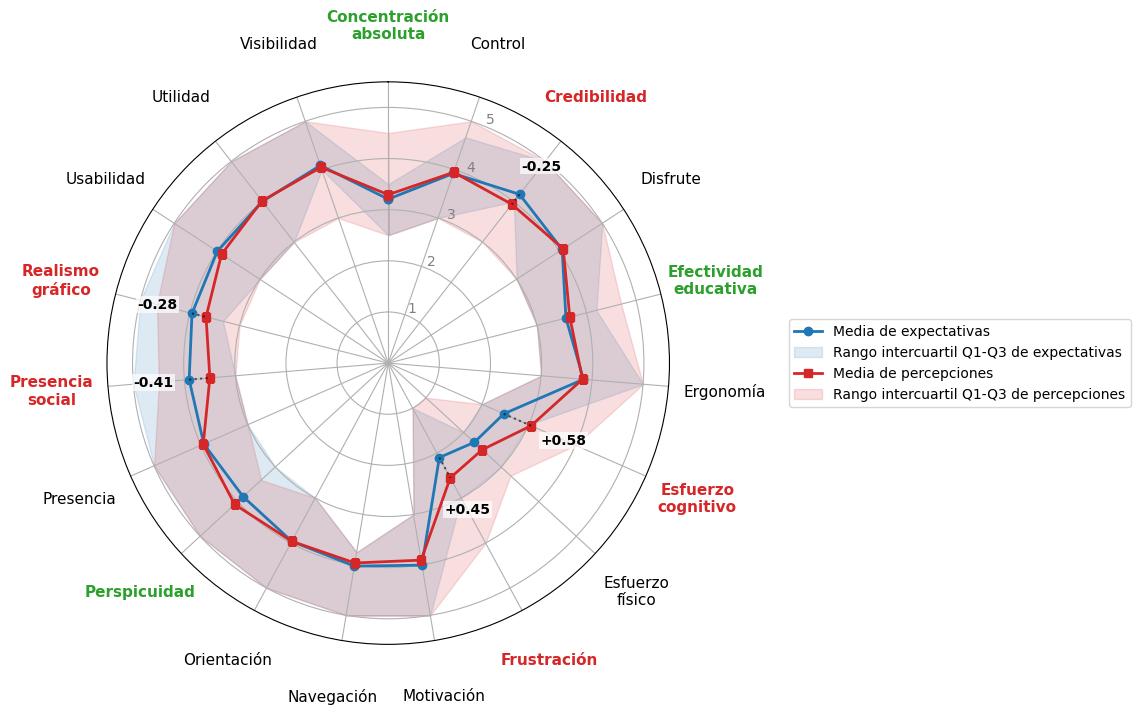

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PROCESAMIENTO DE DATOS ---
file_path = 'Respuestas_expectativas_vs_percepcion.xlsx'

df_header = pd.read_excel(file_path, header=None, nrows=4)
df_datos = pd.read_excel(file_path, skiprows=4, header=None).iloc[:, 6:]

categorias_meta = df_header.iloc[0, 6:].values
constructos_meta = df_header.iloc[1, 6:].values

stats_list = []
for i in range(df_datos.shape[1]):
    col_data = pd.to_numeric(df_datos.iloc[:, i], errors='coerce').dropna()
    if not col_data.empty:
        stats_list.append({
            'Categoria': categorias_meta[i],
            'Constructo': constructos_meta[i],
            'Media': col_data.mean(),
            'Q1': col_data.quantile(0.25),
            'Q3': col_data.quantile(0.75)
        })

df_resumen = pd.DataFrame(stats_list).groupby(['Categoria', 'Constructo']).mean().reset_index()

# --- 2. PREPARACIÓN PARA EL GRÁFICO ---
constructos_originales = df_resumen['Constructo'].unique()
constructos_formateados = [c.replace(' ', '\n') if ' ' in c else c for c in constructos_originales]

angulos = np.linspace(0, 2 * np.pi, len(constructos_originales), endpoint=False).tolist()
angulos += angulos[:1]

def get_metricas(categoria):
    subset = df_resumen[df_resumen['Categoria'] == categoria].set_index('Constructo').reindex(constructos_originales)
    m_val = subset['Media'].tolist()
    q1_val = subset['Q1'].tolist()
    q3_val = subset['Q3'].tolist()
    return (np.array(m_val + [m_val[0]]), np.array(q1_val + [q1_val[0]]), np.array(q3_val + [q3_val[0]]))

val_media_exp, val_q1_exp, val_q3_exp = get_metricas('Expectativa')
val_media_per, val_q1_per, val_q3_per = get_metricas('Percepción')

# --- 3. GENERACIÓN DEL GRÁFICO ---
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Dibujar series
ax.plot(angulos, val_media_exp, color='#1f77b4', label='Media de expectativas', linewidth=2, marker='o', zorder=3)
ax.fill_between(angulos, val_q1_exp, val_q3_exp, color='#1f77b4', alpha=0.15, label='Rango intercuartil Q1-Q3 de expectativas')

ax.plot(angulos, val_media_per, color='#d62728', label='Media de percepciones', linewidth=2, marker='s', zorder=3)
ax.fill_between(angulos, val_q1_per, val_q3_per, color='#d62728', alpha=0.15, label='Rango intercuartil Q1-Q3 de percepciones')

# Ajustes de ejes
ax.tick_params(axis='x', pad=30)
ax.set_ylim(0, 5.5)
ax.set_rticks([1, 2, 3, 4, 5])
ax.tick_params(axis='y', labelsize=10, colors='gray')

# Resaltar Gaps (líneas punteadas y anotaciones)
resaltar_rojo = ["Credibilidad", "Realismo gráfico", "Esfuerzo cognitivo", "Presencia social", "Frustración"]
for i, con in enumerate(constructos_originales):
    if con in resaltar_rojo:
        ax.plot([angulos[i], angulos[i]], [val_media_exp[i], val_media_per[i]],
                color='black', linestyle=':', linewidth=1.5, alpha=0.6, zorder=4)
        diff = val_media_per[i] - val_media_exp[i]
        pos_y = max(val_media_exp[i], val_media_per[i]) + 0.7
        ax.annotate(f"{diff:+.2f}", (angulos[i], pos_y),
                    ha='center', va='center', fontsize=10, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

plt.xticks(angulos[:-1], constructos_formateados, size=11)

# --- DESTACAR ETIQUETAS ESPECÍFICAS (ROJO Y VERDE) ---
resaltar_verde = ["Efectividad educativa", "Perspicuidad", "Concentración absoluta"]

for label, con in zip(ax.get_xticklabels(), constructos_originales):
    if con in resaltar_rojo:
        label.set_color('#d62728')
        label.set_fontweight('bold')
    elif con in resaltar_verde:
        label.set_color('#2ca02c')  # Verde intenso
        label.set_fontweight('bold')

# --- LEYENDA AL COSTADO DERECHO Y VERTICALMENTE AL CENTRO ---
plt.legend(loc='center left', bbox_to_anchor=(1.2, 0.5), ncol=1, frameon=True, fontsize=10)

# Ajustar el espacio horizontal de la figura para que la leyenda lateral no se corte
plt.subplots_adjust(right=0.75)

plt.show()

SPEARMAN CORRELATIONS

Generando matriz de correlación de Dimensiones (Expectativas)...


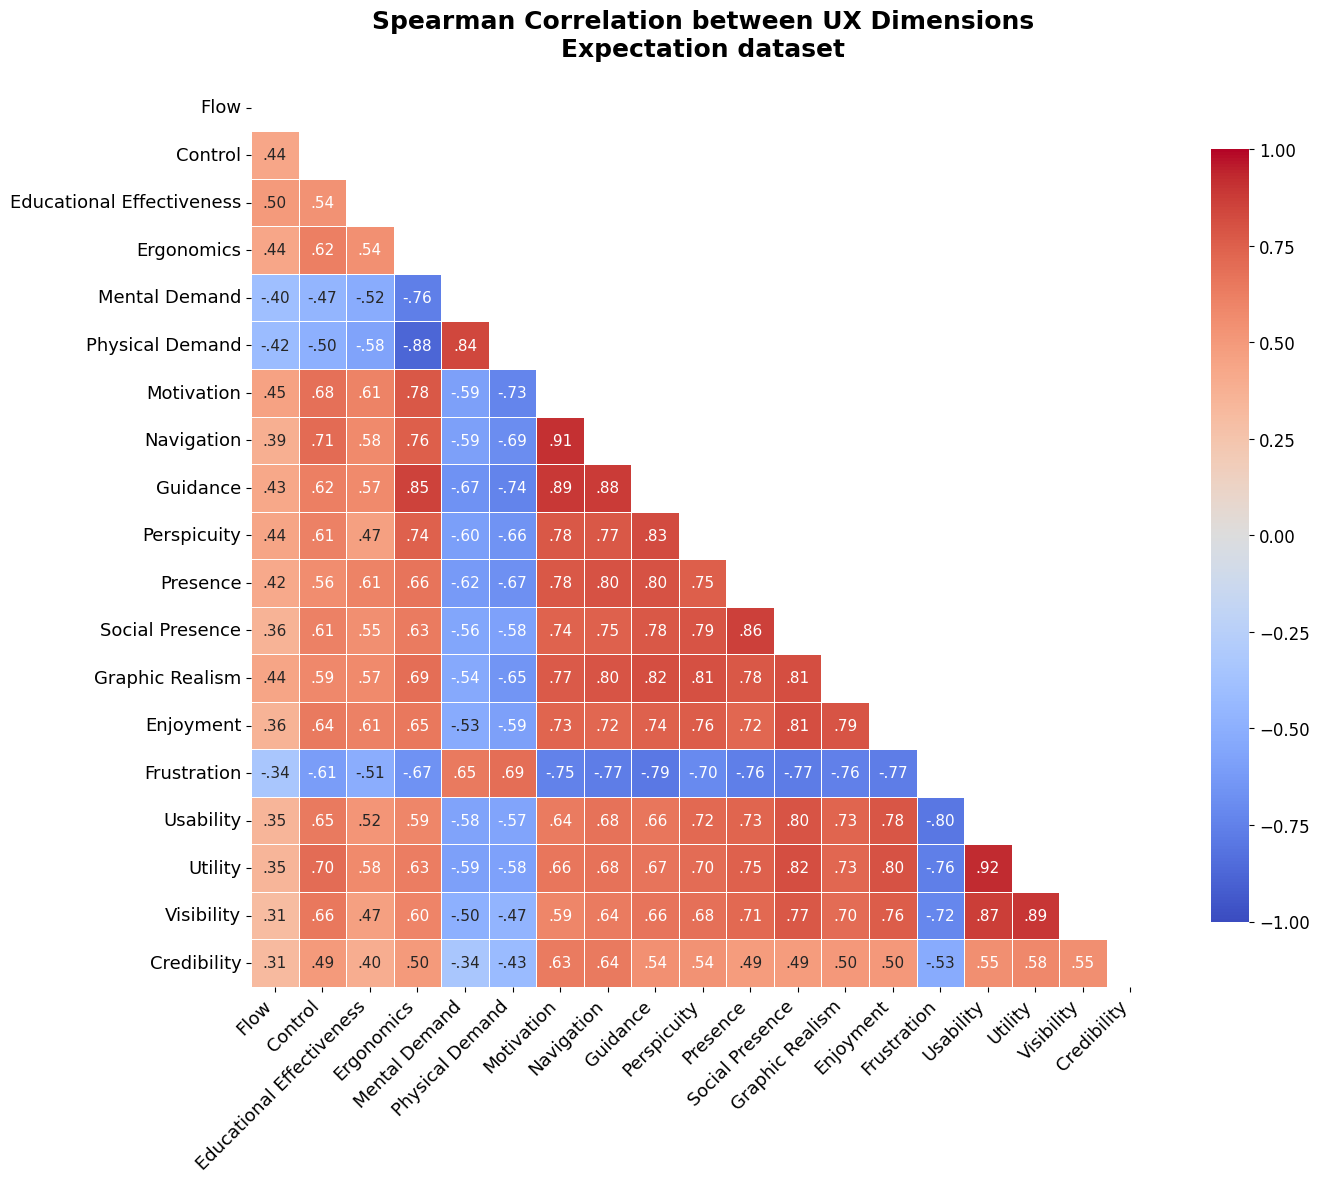

Generando matriz de correlación de Dimensiones (Percepción)...


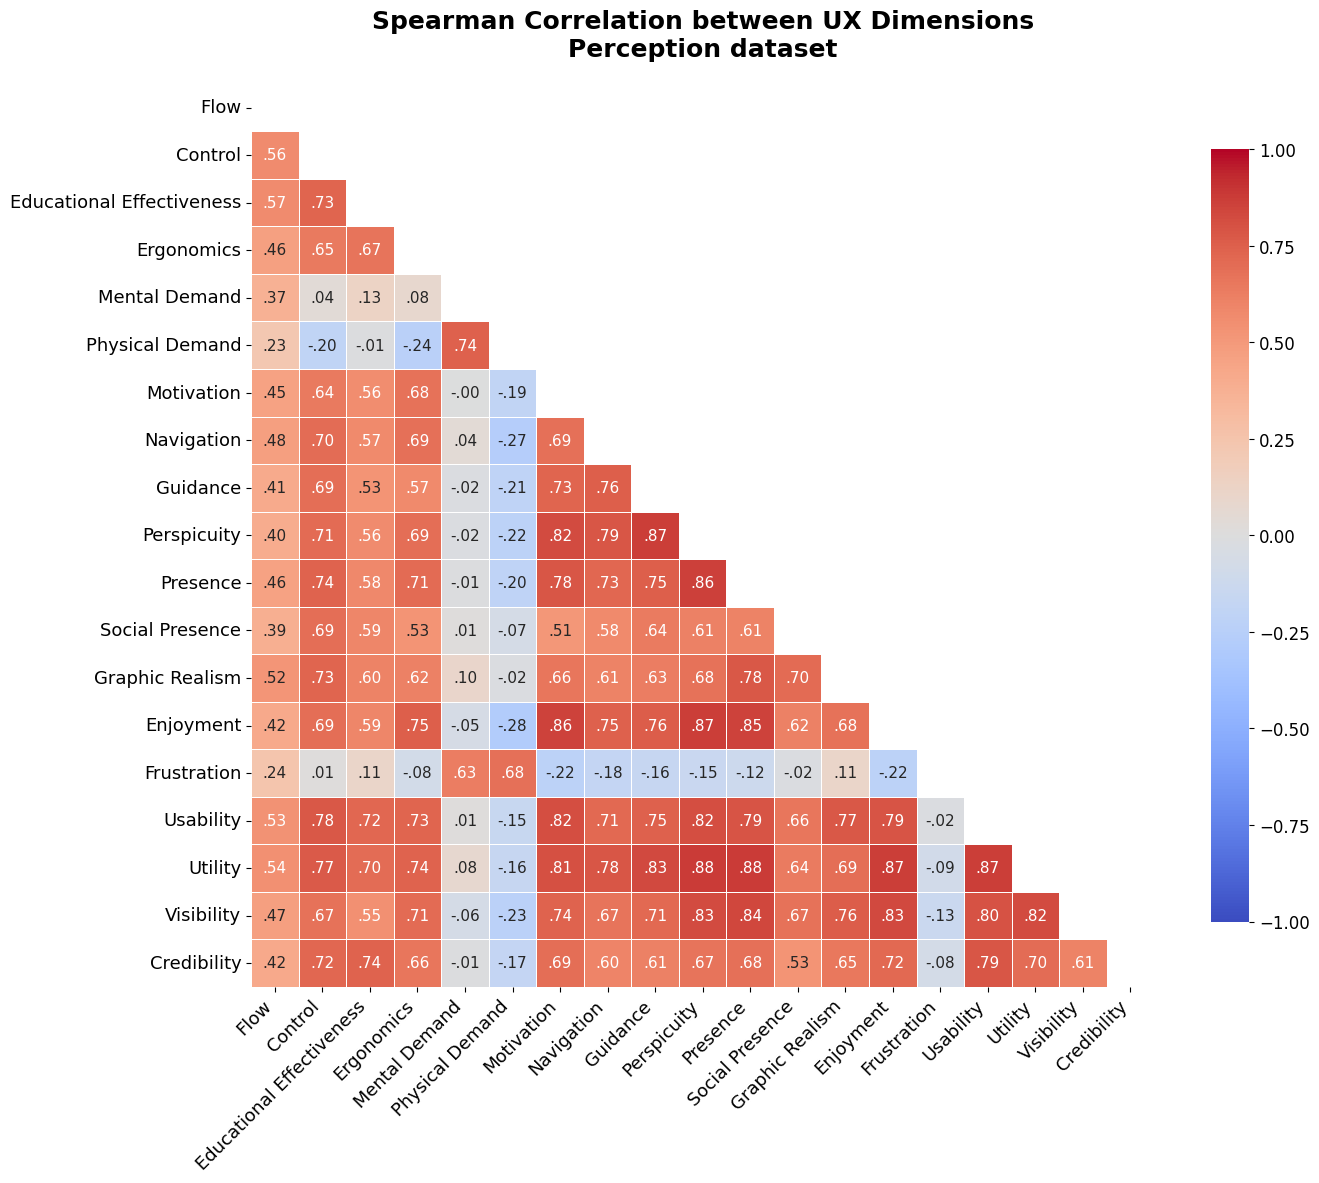

¡Mapas de calor de 19x19 generados exitosamente!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

def generar_heatmap_dimensiones(file_path):
    warnings.filterwarnings('ignore')

    # 1. Cargar el dataset
    df = pd.read_excel(file_path, header=None)
    fila_tipo = df.iloc[0, 6:].astype(str).str.lower()
    fila_dim = df.iloc[1, 6:].astype(str)

    # Extraer las respuestas numéricas a partir de la fila 5
    df_resp = df.iloc[4:, 6:].apply(pd.to_numeric, errors='coerce').reset_index(drop=True)

    # 2. Diccionario de Traducción (Modelo UX completo)
    translation_dict = {
        'Concentración absoluta': 'Flow',
        'Control': 'Control',
        'Efectividad educativa': 'Educational Effectiveness',
        'Ergonomía': 'Ergonomics',
        'Esfuerzo cognitivo': 'Mental Demand',
        'Esfuerzo físico': 'Physical Demand',
        'Motivación': 'Motivation',
        'Navegación': 'Navigation',
        'Orientación': 'Guidance',
        'Perspicuidad': 'Perspicuity',
        'Presencia': 'Presence',
        'Presencia social': 'Social Presence',
        'Realismo gráfico': 'Graphic Realism',
        'Disfrute': 'Enjoyment',
        'Enjoyment': 'Enjoyment',
        'Frustración': 'Frustration',
        'Frustration': 'Frustration',
        'Usabilidad': 'Usability',
        'Utilidad': 'Utility',
        'Visibilidad': 'Visibility',
        'Credibilidad': 'Credibility'
    }

    dimensiones_unicas = fila_dim.unique()

    # DataFrames vacíos para guardar los puntajes agrupados (compuestos)
    df_exp_dim = pd.DataFrame()
    df_perc_dim = pd.DataFrame()

    # 3. Agrupar ítems por dimensión (Puntaje compuesto por participante)
    for dim in dimensiones_unicas:
        idx_dim = [i for i, d in enumerate(fila_dim) if d == dim]
        cols_exp = [i for i in idx_dim if 'expectativa' in fila_tipo.iloc[i]]
        cols_perc = [i for i in idx_dim if 'percepcion' in fila_tipo.iloc[i] or 'percepción' in fila_tipo.iloc[i]]

        dim_en = translation_dict.get(dim, str(dim))

        df_exp_dim[dim_en] = df_resp.iloc[:, cols_exp].median(axis=1)
        df_perc_dim[dim_en] = df_resp.iloc[:, cols_perc].median(axis=1)

    # 4. Calcular matrices de correlación de Spearman (19x19)
    corr_exp = df_exp_dim.corr(method='spearman')
    corr_perc = df_perc_dim.corr(method='spearman')

    # --- NUEVO: Función para formatear el texto truncando el cero ---
    def formato_truncado(x):
        if pd.isna(x):
            return ""
        s = f"{x:.2f}"
        if s.startswith("0."):
            return s[1:]
        elif s.startswith("-0."):
            return "-" + s[2:]
        return s

    # 5. Función de graficado
    def plot_dimension_heatmap(corr_matrix, titulo, filename):
        # Aumentamos el figsize para tener más espacio visual
        fig, ax = plt.subplots(figsize=(14, 12))

        # Generar máscara para ocultar la mitad superior
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

        # Generar la matriz de anotaciones formateadas usando nuestra función
        annot_array = corr_matrix.applymap(formato_truncado).values

        # Dibujar Mapa de calor
        # Reemplazamos annot=True por annot=annot_array y fmt=""
        sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, center=0,
                    square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=ax,
                    annot=annot_array, fmt="", annot_kws={"size": 11, "weight": "medium"})

        # Título más grande
        plt.title(titulo, fontsize=18, fontweight='bold', pad=20)

        # Etiquetas de los ejes X e Y más grandes
        plt.xticks(rotation=45, ha='right', fontsize=13)
        plt.yticks(fontsize=13)

        # Aumentar la fuente de los números en la barra lateral de color (Colorbar)
        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=12)

        plt.tight_layout()
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

    # 6. Ejecutar función
    print("Generando matriz de correlación de Dimensiones (Expectativas)...")
    plot_dimension_heatmap(corr_exp, "Spearman Correlation between UX Dimensions\nExpectation dataset", "heatmap_dim_expectativas.png")

    print("Generando matriz de correlación de Dimensiones (Percepción)...")
    plot_dimension_heatmap(corr_perc, "Spearman Correlation between UX Dimensions\nPerception dataset", "heatmap_dim_percepcion.png")

    print("¡Mapas de calor de 19x19 generados exitosamente!")

# Ejecutar script
generar_heatmap_dimensiones('Respuestas_expectativas_vs_percepcion.xlsx')

MULTICOLINEALITY TEST

In [ ]:
import pandas as pd
import numpy as np
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def evaluar_multicolinealidad_vif(file_path):
    warnings.filterwarnings('ignore')

    # 1. Cargar el dataset
    try:
        df = pd.read_excel(file_path, header=None)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{file_path}'.")
        return

    fila_tipo = df.iloc[0, 6:].astype(str).str.lower()
    fila_dim = df.iloc[1, 6:].astype(str)

    cols_exp = []
    cols_perc = []
    nombres_items = []

    # 2. Separar columnas de Expectativas y Percepción
    for i in range(len(fila_tipo)):
        if 'expectativa' in fila_tipo.iloc[i]:
            cols_exp.append(i + 6)
            # Guardamos el nombre de la dimensión como referencia del ítem
            nombres_items.append(f"Item {len(cols_exp)} ({fila_dim.iloc[i]})")
        elif 'percepcion' in fila_tipo.iloc[i] or 'percepción' in fila_tipo.iloc[i]:
            cols_perc.append(i + 6)

    # Extraer las respuestas numéricas y forzar conversión
    df_resp = df.iloc[4:, :].reset_index(drop=True)

    # Es vital eliminar las filas con NaNs (participantes con datos incompletos),
    # ya que statsmodels no puede calcular el VIF con valores nulos.
    df_exp = df_resp[cols_exp].apply(pd.to_numeric, errors='coerce').dropna()
    df_perc = df_resp[cols_perc].apply(pd.to_numeric, errors='coerce').dropna()

    df_exp.columns = nombres_items
    df_perc.columns = nombres_items

    # 3. Función interna para calcular VIF
    def calcular_vif(dataframe, nombre_dataset):
        # Se añade una constante (intercepto) obligatoria para que el cálculo del R^2 (y por ende el VIF) sea matemáticamente correcto
        df_const = add_constant(dataframe)

        resultados_vif = pd.DataFrame()
        resultados_vif["Item"] = dataframe.columns

        # Calcular VIF iterando por cada columna (saltando la constante en el índice 0)
        valores_vif = []
        for i in range(dataframe.shape[1]):
            # i + 1 porque la columna 0 es la constante
            vif = variance_inflation_factor(df_const.values, i + 1)
            valores_vif.append(vif)

        resultados_vif["VIF"] = valores_vif

        # Ordenar de mayor a menor colinealidad
        resultados_vif = resultados_vif.sort_values(by="VIF", ascending=False).reset_index(drop=True)

        # 4. Impresión del reporte
        print("\n" + "="*75)
        print(f"  ANÁLISIS DE COLINEALIDAD (VIF) - DATASET: {nombre_dataset.upper()}")
        print("="*75)
        print(f"Participantes válidos analizados: {len(dataframe)}")
        print("-" * 75)
        print(f"{'Ítem (Dimensión)':<45} | {'VIF':>8} | {'Diagnóstico'}")
        print("-" * 75)

        items_criticos = 0
        for _, row in resultados_vif.iterrows():
            vif_val = row['VIF']
            if vif_val >= 10:
                diag = "CRÍTICO (Severa colinealidad)"
                items_criticos += 1
            elif vif_val >= 5:
                diag = "ALERTA (Alta colinealidad)"
            else:
                diag = "OK (Aceptable)"

            print(f"{row['Item']:<45} | {vif_val:>8.2f} | {diag}")

        print("-" * 75)
        print(f"Resumen: {items_criticos} ítems superan el umbral crítico de VIF > 10.")
        print("="*75 + "\n")

        return resultados_vif

    # 5. Ejecutar análisis para ambos datasets
    print("Iniciando cálculo de VIF (puede tomar unos segundos dependiendo de la varianza)...")
    vif_expectativas = calcular_vif(df_exp, "Expectativas")
    vif_percepcion = calcular_vif(df_perc, "Percepción")

# Ejecutar script
evaluar_multicolinealidad_vif('Respuestas_expectativas_vs_percepcion.xlsx')

Iniciando cálculo de VIF (puede tomar unos segundos dependiendo de la varianza)...

  ANÁLISIS DE COLINEALIDAD (VIF) - DATASET: EXPECTATIVAS
Participantes válidos analizados: 80
---------------------------------------------------------------------------
Ítem (Dimensión)                              |      VIF | Diagnóstico
---------------------------------------------------------------------------
Item 39 (Credibilidad)                        |    41.88 | CRÍTICO (Severa colinealidad)
Item 19 (Orientación)                         |    38.57 | CRÍTICO (Severa colinealidad)
Item 17 (Motivación)                          |    37.00 | CRÍTICO (Severa colinealidad)
Item 40 (Credibilidad)                        |    35.73 | CRÍTICO (Severa colinealidad)
Item 32 (Utilidad)                            |    31.89 | CRÍTICO (Severa colinealidad)
Item 15 (Esfuerzo físico)                     |    29.66 | CRÍTICO (Severa colinealidad)
Item 14 (Esfuerzo cognitivo)                  |    24.74 | CRÍTIC

CRONBACHS ALPHA

In [ ]:
import pandas as pd
import numpy as np
import warnings

def analisis_cronbach_completo(file_path):
    warnings.filterwarnings('ignore')

    # 1. Cargar el dataset
    try:
        df = pd.read_excel(file_path, header=None)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{file_path}'.")
        return

    fila_tipo = df.iloc[0, 6:].astype(str).str.lower()
    fila_dim = df.iloc[1, 6:].astype(str)

    # Extraer respuestas numéricas y limpiar NaNs (filas incompletas)
    df_resp = df.iloc[4:, 6:].apply(pd.to_numeric, errors='coerce').dropna().reset_index(drop=True)

    translation_dict = {
        'Concentración absoluta': 'Flow',
        'Control': 'Control',
        'Efectividad educativa': 'Educational Effectiveness',
        'Ergonomía': 'Ergonomics',
        'Esfuerzo cognitivo': 'Mental Demand',
        'Esfuerzo físico': 'Physical Demand',
        'Motivación': 'Motivation',
        'Navegación': 'Navigation',
        'Orientación': 'Guidance',
        'Perspicuidad': 'Perspicuity',
        'Presencia': 'Presence',
        'Presencia social': 'Social Presence',
        'Realismo gráfico': 'Graphic Realism',
        'Disfrute': 'Enjoyment',
        'Enjoyment': 'Enjoyment',
        'Frustración': 'Frustration',
        'Frustration': 'Frustration',
        'Usabilidad': 'Usability',
        'Utilidad': 'Utility',
        'Visibilidad': 'Visibility',
        'Credibilidad': 'Credibility'
    }

    dimensiones_unicas = fila_dim.unique()

    # Identificar todas las columnas de Expectativas y Percepción
    cols_exp_global = [i for i, tipo in enumerate(fila_tipo) if 'expectativa' in tipo]
    cols_perc_global = [i for i, tipo in enumerate(fila_tipo) if 'percepcion' in tipo or 'percepción' in tipo]

    # 2. Función matemática para calcular el Alfa de Cronbach
    def cronbach_alpha(dataframe):
        k = dataframe.shape[1]
        if k <= 1:
            return np.nan # No se puede calcular alfa con un solo ítem

        varianzas_items = dataframe.var(ddof=1)
        varianza_total = dataframe.sum(axis=1).var(ddof=1)

        if varianza_total == 0:
            return np.nan

        alpha = (k / (k - 1)) * (1 - varianzas_items.sum() / varianza_total)
        return alpha

    # 3. Calcular Alfas Globales
    alpha_exp_global = cronbach_alpha(df_resp.iloc[:, cols_exp_global])
    alpha_perc_global = cronbach_alpha(df_resp.iloc[:, cols_perc_global])

    print("\n" + "="*80)
    print("   ANÁLISIS DE CONSISTENCIA INTERNA (ALFA DE CRONBACH)")
    print("="*80)
    print(f"Alfa de Cronbach Global - Expectativas: {alpha_exp_global:.4f}")
    print(f"Alfa de Cronbach Global - Percepción:   {alpha_perc_global:.4f}")
    print("="*80 + "\n")

    resultados = []

    # 4. Iterar por cada dimensión para cálculos locales y de impacto (if deleted)
    for dim in dimensiones_unicas:
        dim_en = translation_dict.get(dim, str(dim))

        # Encontrar columnas específicas de esta dimensión
        idx_dim = [i for i, d in enumerate(fila_dim) if d == dim]
        cols_exp_dim = [i for i in idx_dim if 'expectativa' in fila_tipo.iloc[i]]
        cols_perc_dim = [i for i in idx_dim if 'percepcion' in fila_tipo.iloc[i] or 'percepción' in fila_tipo.iloc[i]]

        # Alfa local de la dimensión
        alpha_exp_local = cronbach_alpha(df_resp.iloc[:, cols_exp_dim])
        alpha_perc_local = cronbach_alpha(df_resp.iloc[:, cols_perc_dim])

        # Calcular el impacto (Alfa global SIN esta dimensión)
        cols_exp_sin_dim = [c for c in cols_exp_global if c not in cols_exp_dim]
        cols_perc_sin_dim = [c for c in cols_perc_global if c not in cols_perc_dim]

        alpha_exp_deleted = cronbach_alpha(df_resp.iloc[:, cols_exp_sin_dim])
        alpha_perc_deleted = cronbach_alpha(df_resp.iloc[:, cols_perc_sin_dim])

        # Determinar si la dimensión reduce la consistencia del modelo
        # Si el alfa SIN la dimensión es MAYOR al alfa global, la dimensión estaba restando fiabilidad
        impacto_exp = "Reduce fiabilidad" if alpha_exp_deleted > alpha_exp_global else "Aporta/Neutral"
        impacto_perc = "Reduce fiabilidad" if alpha_perc_deleted > alpha_perc_global else "Aporta/Neutral"

        resultados.append({
            'Dimensión': dim_en,
            'Alfa Exp': alpha_exp_local,
            'Alfa Perc': alpha_perc_local,
            'Alfa Global si se elimina (Exp)': alpha_exp_deleted,
            'Impacto en Expectativas': impacto_exp,
            'Alfa Global si se elimina (Perc)': alpha_perc_deleted,
            'Impacto en Percepción': impacto_perc
        })

    df_res = pd.DataFrame(resultados)

    # 5. Imprimir tabla de Alfas Locales (Por dimensión)
    print("--- ALFA DE CRONBACH POR DIMENSIÓN ---")
    print(f"{'Dimensión':<26} | {'Alfa Exp':>8} | {'Alfa Perc':>8}")
    print("-" * 48)
    for _, row in df_res.iterrows():
        a_e = f"{row['Alfa Exp']:.3f}" if pd.notna(row['Alfa Exp']) else "N/A"
        a_p = f"{row['Alfa Perc']:.3f}" if pd.notna(row['Alfa Perc']) else "N/A"
        print(f"{row['Dimensión']:<26} | {a_e:>8} | {a_p:>8}")
    print("Nota: 'N/A' ocurre si la dimensión tiene solo 1 ítem (no hay varianza compartida).\n")

    # 6. Imprimir tabla de Impacto (Dimensiones problemáticas)
    print("--- IMPACTO EN LA FIABILIDAD (ALFA SI SE ELIMINA LA DIMENSIÓN) ---")
    print("Identifica qué dimensiones reducen la consistencia interna del dataset.")
    print("-" * 90)
    print(f"{'Dimensión':<26} | {'Alfa si borra (Exp)':>19} | {'Impacto Exp':>18} | {'Alfa si borra (Perc)':>20} | {'Impacto Perc':>18}")
    print("-" * 90)

    for _, row in df_res.iterrows():
        # Formatear visualmente las problemáticas
        imp_e = f"** {row['Impacto en Expectativas']} **" if row['Impacto en Expectativas'] == "Reduce fiabilidad" else row['Impacto en Expectativas']
        imp_p = f"** {row['Impacto en Percepción']} **" if row['Impacto en Percepción'] == "Reduce fiabilidad" else row['Impacto en Percepción']

        print(f"{row['Dimensión']:<26} | {row['Alfa Global si se elimina (Exp)']:>19.4f} | {imp_e:>18} | {row['Alfa Global si se elimina (Perc)']:>20.4f} | {imp_p:>18}")

    print("-" * 90)
    print("="*90 + "\n")

# Ejecutar el script
analisis_cronbach_completo('Respuestas_expectativas_vs_percepcion.xlsx')


   ANÁLISIS DE CONSISTENCIA INTERNA (ALFA DE CRONBACH)
Alfa de Cronbach Global - Expectativas: 0.9578
Alfa de Cronbach Global - Percepción:   0.9753

--- ALFA DE CRONBACH POR DIMENSIÓN ---
Dimensión                  | Alfa Exp | Alfa Perc
------------------------------------------------
Flow                       |    0.087 |    0.436
Control                    |    0.940 |    0.924
Educational Effectiveness  |    0.880 |    0.940
Ergonomics                 |    0.783 |    0.825
Mental Demand              |    0.738 |    0.565
Physical Demand            |      N/A |      N/A
Motivation                 |    0.914 |    0.919
Navigation                 |      N/A |      N/A
Guidance                   |      N/A |      N/A
Perspicuity                |    0.871 |    0.971
Presence                   |      N/A |      N/A
Social Presence            |    0.946 |    0.927
Graphic Realism            |    0.941 |    0.917
Enjoyment                  |      N/A |      N/A
Frustration              

Clusterizacion con spearman

Generando el dendrograma de Expectativas...


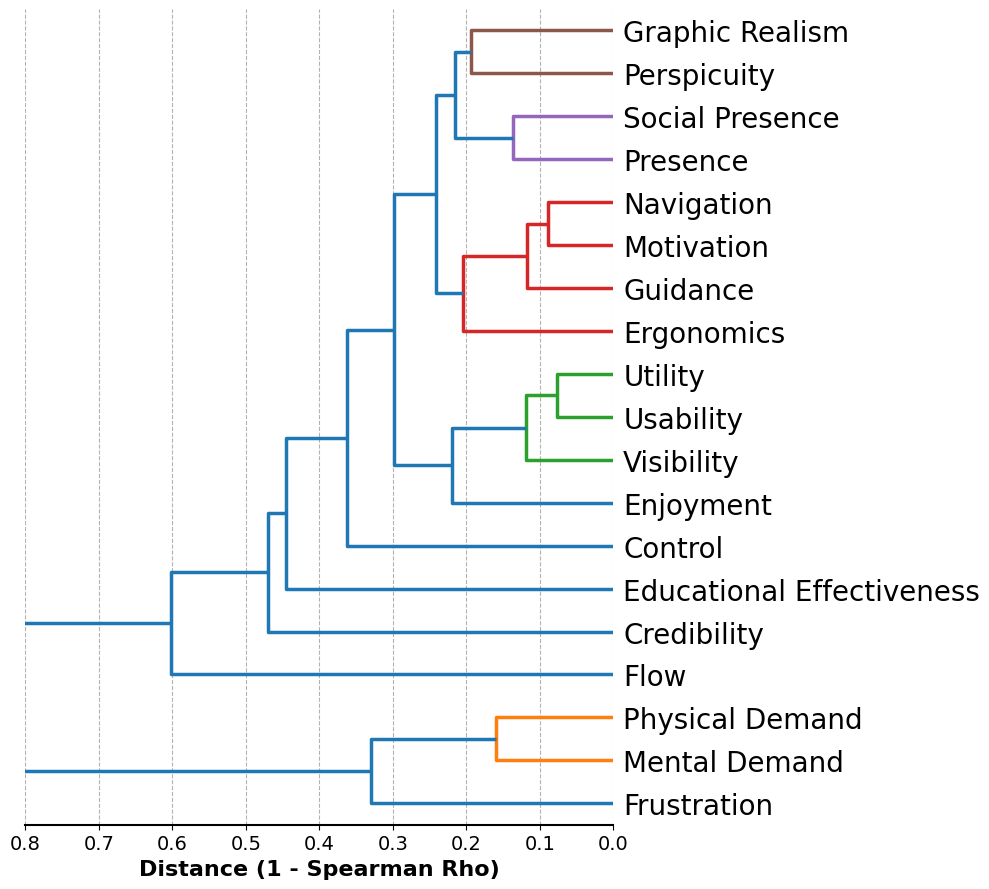

Generando el dendrograma de Percepción...


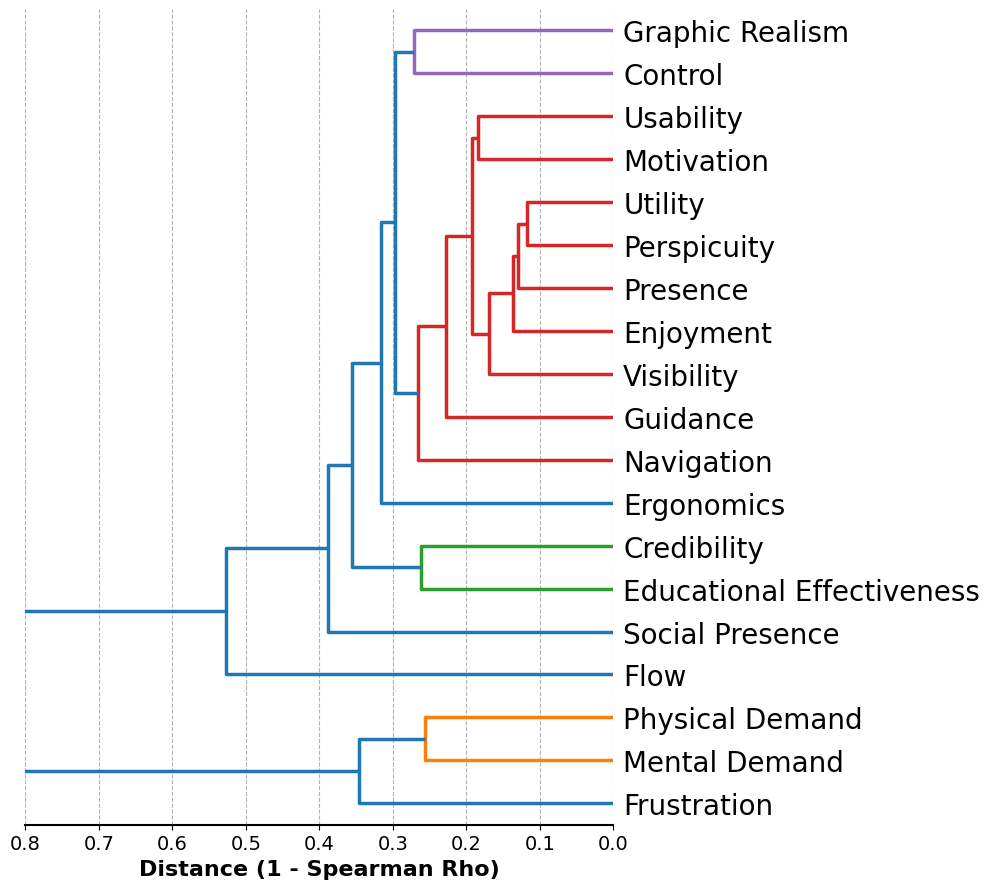


¡Gráficos separados generados exitosamente! Revisa los nuevos archivos PNG.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import warnings

def generar_dendrogramas_separados(file_path):
    warnings.filterwarnings('ignore')

    # 1. Cargar el dataset y metadatos
    try:
        df = pd.read_excel(file_path, header=None)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{file_path}'.")
        return

    fila_tipo = df.iloc[0, 6:].astype(str).str.lower()
    fila_dim = df.iloc[1, 6:].astype(str)

    df_resp = df.iloc[4:, 6:].apply(pd.to_numeric, errors='coerce').reset_index(drop=True)

    translation_dict = {
        'Concentración absoluta': 'Flow',
        'Control': 'Control',
        'Efectividad educativa': 'Educational Effectiveness',
        'Ergonomía': 'Ergonomics',
        'Esfuerzo cognitivo': 'Mental Demand',
        'Esfuerzo físico': 'Physical Demand',
        'Motivación': 'Motivation',
        'Navegación': 'Navigation',
        'Orientación': 'Guidance',
        'Perspicuidad': 'Perspicuity',
        'Presencia': 'Presence',
        'Presencia social': 'Social Presence',
        'Realismo gráfico': 'Graphic Realism',
        'Disfrute': 'Enjoyment',
        'Enjoyment': 'Enjoyment',
        'Frustración': 'Frustration',
        'Frustration': 'Frustration',
        'Usabilidad': 'Usability',
        'Utilidad': 'Utility',
        'Visibilidad': 'Visibility',
        'Credibilidad': 'Credibility'
    }

    dimensiones_unicas = fila_dim.unique()

    df_exp_dim = pd.DataFrame()
    df_perc_dim = pd.DataFrame()

    # 2. Agrupar ítems por dimensión (Mediana compuesta)
    for dim in dimensiones_unicas:
        idx_dim = [i for i, d in enumerate(fila_dim) if d == dim]
        cols_exp = [i for i in idx_dim if 'expectativa' in fila_tipo.iloc[i]]
        cols_perc = [i for i in idx_dim if 'percepcion' in fila_tipo.iloc[i] or 'percepción' in fila_tipo.iloc[i]]

        dim_en = translation_dict.get(dim, str(dim))

        df_exp_dim[dim_en] = df_resp.iloc[:, cols_exp].median(axis=1)
        df_perc_dim[dim_en] = df_resp.iloc[:, cols_perc].median(axis=1)

    # 3. Calcular Matrices de Correlación de Spearman
    corr_exp = df_exp_dim.corr(method='spearman')
    corr_perc = df_perc_dim.corr(method='spearman')

    # 4. Transformar Correlación a Distancia (Distancia = 1 - Rho)
    dist_exp = 1 - corr_exp
    dist_perc = 1 - corr_perc

    condensed_exp = squareform(np.clip(dist_exp.values, 0, 2), checks=False)
    condensed_perc = squareform(np.clip(dist_perc.values, 0, 2), checks=False)

    # 5. Calcular el Enlace Jerárquico (UPGMA)
    linkage_exp = linkage(condensed_exp, method='average')
    linkage_perc = linkage(condensed_perc, method='average')

    # 6. Definir un factor de umbral más estricto para forzar más colores
    color_factor = 0.21
    thresh_exp = color_factor
    thresh_perc = color_factor + 0.08

    # --- FUNCIÓN DE DIBUJO INDIVIDUAL ACTUALIZADA ---
    def plot_single_dendrogram(linkage_matrix, labels, filename, color_thresh):
        plt.rcParams['lines.linewidth'] = 2.5
        plt.figure(figsize=(10, 9))

        dendrogram(linkage_matrix,
                   labels=labels,
                   orientation='left',
                   leaf_font_size=20,
                   color_threshold=color_thresh)

        plt.xlabel('Distance (1 - Spearman Rho)', fontsize=16, fontweight='bold')
        plt.xticks(fontsize=14)

        ax = plt.gca()

        # --- NUEVO: Ocultar uniones que superan el umbral visual ---
        distancia_corte = 0.8
        for line in ax.lines:
            x_data = line.get_xdata()
            # En orientation='left', x_data contiene las distancias de la unión.
            # Si el punto más lejano de la línea supera el corte, la ocultamos entera.
            if max(x_data) > distancia_corte:
                line.set_visible(False)

        # Ajustar el límite del gráfico al punto de corte exacto
        ax.set_xlim(distancia_corte, 0)

        # Eliminar bordes innecesarios
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_linewidth(1.5)

        ax.xaxis.grid(True, linestyle='--', alpha=0.6, color='gray')
        ax.set_axisbelow(True)

        plt.tight_layout()
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

        plt.rcParams['lines.linewidth'] = 1.75

    # 7. Generar e imprimir los gráficos por separado
    print("Generando el dendrograma de Expectativas...")
    plot_single_dendrogram(linkage_exp, corr_exp.columns,
                           'Dendrograma_Expectativas.png', thresh_exp)

    print("Generando el dendrograma de Percepción...")
    plot_single_dendrogram(linkage_perc, corr_perc.columns,
                           'Dendrograma_Percepcion.png', thresh_perc)

    print("\n¡Gráficos separados generados exitosamente! Revisa los nuevos archivos PNG.")

# Ejecutar el script
generar_dendrogramas_separados('Respuestas_expectativas_vs_percepcion.xlsx')

ANALISIS SINTOMAS

In [ ]:
import pandas as pd

file_path = "Proyecto DD - Avatar RV con IA (respuestas)_SOFIA.xlsx"

# 1. Leer el Excel con el doble encabezado
df = pd.read_excel(file_path, header=[0, 1])

# 2. Aislar la columna de participantes para analizarla
participantes_temp = df.iloc[:, 0]

# 3. Identificar la posición exacta de la primera celda vacía (inicio de la brecha)
primer_vacio_idx = participantes_temp.isna().idxmax()

# 4. Recortar el dataframe maestro para conservar ÚNICAMENTE las filas superiores a la brecha
df_limpio = df.iloc[:primer_vacio_idx]

# 5. Extraer la columna de participantes ya limpia y nombrarla
participantes = df_limpio.iloc[:, 0].copy()
participantes.name = "Participante"

# 6. Filtrar las columnas Before y After del dataframe limpio
cols_before = df_limpio.xs('Before', axis=1, level=1)
cols_after = df_limpio.xs('After', axis=1, level=1)

# 7. Unir y crear los datasets finales
df_before = pd.concat([participantes, cols_before], axis=1)
df_after = pd.concat([participantes, cols_after], axis=1)

# 8. Imprimir resultados
print(f"Cantidad real de registros Before: {len(df_before)}")
print(f"Cantidad real de registros After: {len(df_after)}")

Cantidad real de registros Before: 80
Cantidad real de registros After: 80


In [ ]:
import pandas as pd
from scipy.stats import shapiro

# 1. Carga y limpieza de datos (código base)
file_path = "Proyecto DD - Avatar RV con IA (respuestas)_SOFIA.xlsx"
df = pd.read_excel(file_path, header=[0, 1])

# Aislamos a los participantes y cortamos en el primer espacio vacío
primer_vacio_idx = df.iloc[:, 0].isna().idxmax()
df_limpio = df.iloc[:primer_vacio_idx]

participantes = df_limpio.iloc[:, 0].copy()
participantes.name = "Participante"

cols_before = df_limpio.xs('Before', axis=1, level=1)
cols_after = df_limpio.xs('After', axis=1, level=1)

df_before = pd.concat([participantes, cols_before], axis=1)
df_after = pd.concat([participantes, cols_after], axis=1)

# 2. Análisis de normalidad (Shapiro-Wilk) ítem por ítem
print("=== Prueba de Normalidad de Shapiro-Wilk ===")
print("H0: Los datos provienen de una distribución normal (p > 0.05)")
print("H1: Los datos NO provienen de una distribución normal (p <= 0.05)\n")

# Obtenemos la lista de los 10 síntomas (ignorando la columna 'Participante')
sintomas = cols_before.columns.tolist()

# Lista para almacenar los resultados
resultados = []

for sintoma in sintomas:
    # Extraemos los datos numéricos y omitimos posibles valores nulos
    data_before = df_before[sintoma].dropna()
    data_after = df_after[sintoma].dropna()

    # Shapiro-Wilk para el dataset 'Before'
    stat_b, p_val_b = shapiro(data_before)
    normal_b = "Sí" if p_val_b > 0.05 else "No"

    # Shapiro-Wilk para el dataset 'After'
    stat_a, p_val_a = shapiro(data_after)
    normal_a = "Sí" if p_val_a > 0.05 else "No"

    # Guardamos el resumen del síntoma
    resultados.append({
        "Síntoma": sintoma,
        "W (Before)": round(stat_b, 4),
        "p-val (Before)": round(p_val_b, 4),
        "Normal? (B)": normal_b,
        "W (After)": round(stat_a, 4),
        "p-val (After)": round(p_val_a, 4),
        "Normal? (A)": normal_a
    })

# 3. Presentación de los resultados
# Convertimos a DataFrame para imprimir una tabla limpia por consola
df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

=== Prueba de Normalidad de Shapiro-Wilk ===
H0: Los datos provienen de una distribución normal (p > 0.05)
H1: Los datos NO provienen de una distribución normal (p <= 0.05)

                 Síntoma  W (Before)  p-val (Before) Normal? (B)  W (After)  p-val (After) Normal? (A)
      General discomfort      0.6148             0.0          No     0.6978            0.0          No
          Disorientation      0.5091             0.0          No     0.5811            0.0          No
         Loss of balance      0.5770             0.0          No     0.5982            0.0          No
Difficulty concentrating      0.5821             0.0          No     0.6226            0.0          No
          Blurred vision      0.6418             0.0          No     0.7112            0.0          No
             Eye fatigue      0.6044             0.0          No     0.6909            0.0          No
                Headache      0.6298             0.0          No     0.6383            0.0          No
  

In [ ]:
import pandas as pd
from scipy.stats import wilcoxon

# 1. Carga y limpieza de datos
file_path = "Proyecto DD - Avatar RV con IA (respuestas)_SOFIA.xlsx"
df = pd.read_excel(file_path, header=[0, 1])

# Recortar hasta la primera fila vacía (conserva solo los 80 participantes)
primer_vacio_idx = df.iloc[:, 0].isna().idxmax()
df_limpio = df.iloc[:primer_vacio_idx]

# Separar variables
cols_before = df_limpio.xs('Before', axis=1, level=1)
cols_after = df_limpio.xs('After', axis=1, level=1)

# 2. Configuración de la evaluación
print("=== Prueba de Wilcoxon por Niveles de Significancia ===")
print("H0: No hay diferencia significativa entre el Antes y el Después.")
print("[X] -> Se RECHAZA H0 (p <= alfa) | [✓] -> Se ACEPTA H0 (p > alfa)\n")

sintomas = cols_before.columns.tolist()
resultados = []

# Función auxiliar para asignar el símbolo correcto
def evaluar_hipotesis(p, alfa):
    if p is None:
        return "-"
    # Si p <= alfa, rechazamos H0 (X). Si p > alfa, aceptamos H0 (✓)
    return "X" if p <= alfa else "✓"

for sintoma in sintomas:
    data_before = cols_before[sintoma].dropna()
    data_after = cols_after[sintoma].dropna()

    indices_comunes = data_before.index.intersection(data_after.index)

    # Forzar conversión numérica para evitar el error de cálculo anterior
    x = pd.to_numeric(data_before.loc[indices_comunes], errors='coerce')
    y = pd.to_numeric(data_after.loc[indices_comunes], errors='coerce')

    valid_mask = x.notna() & y.notna()
    x = x[valid_mask]
    y = y[valid_mask]

    # Cálculo de Wilcoxon
    if (x == y).all():
        p_val = None
    else:
        try:
            stat, p_val = wilcoxon(x, y)
        except Exception:
            p_val = None

    # Almacenar resultados
    resultados.append({
        "Síntoma": sintoma,
        "p-valor": round(p_val, 4) if p_val is not None else "-",
        "α = 0.05": evaluar_hipotesis(p_val, 0.05),
        "α = 0.01": evaluar_hipotesis(p_val, 0.01),
        "α = 0.001": evaluar_hipotesis(p_val, 0.001)
    })

# 3. Impresión de la tabla final
df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

=== Prueba de Wilcoxon por Niveles de Significancia ===
H0: No hay diferencia significativa entre el Antes y el Después.
[X] -> Se RECHAZA H0 (p <= alfa) | [✓] -> Se ACEPTA H0 (p > alfa)

                 Síntoma  p-valor α = 0.05 α = 0.01 α = 0.001
      General discomfort   0.0112        X        ✓         ✓
          Disorientation   0.0306        X        ✓         ✓
         Loss of balance   0.1882        ✓        ✓         ✓
Difficulty concentrating   0.0577        ✓        ✓         ✓
          Blurred vision   0.0436        X        ✓         ✓
             Eye fatigue   0.0209        X        ✓         ✓
                Headache   0.2890        ✓        ✓         ✓
               Dizziness   0.9259        ✓        ✓         ✓
                Sweating   0.4941        ✓        ✓         ✓
                  Nausea   0.9173        ✓        ✓         ✓


In [ ]:
import pandas as pd
from scipy.stats import spearmanr

# 1. Carga y limpieza de datos (80 participantes exactos)
file_path = "Proyecto DD - Avatar RV con IA (respuestas)_SOFIA.xlsx"
df = pd.read_excel(file_path, header=[0, 1])

primer_vacio_idx = df.iloc[:, 0].isna().idxmax()
df_limpio = df.iloc[:primer_vacio_idx].copy()

# 2. Extracción y transformación de las escalas de experiencia
col_b_raw = df_limpio.iloc[:, 1].astype(str).str.strip().str.capitalize()
col_c_raw = df_limpio.iloc[:, 2].astype(str).str.strip().str.capitalize()

mapeo_likert = {
    'Muy bajo': 1,
    'Bajo': 2,
    'Intermedio': 3,
    'Alto': 4,
    'Muy alto': 5
}

df_limpio['Likert_RV'] = col_b_raw.map(mapeo_likert)
df_limpio['Likert_Simuladores'] = col_c_raw.map(mapeo_likert)

# 3. Preparación de los datos 'After' y variables de evaluación
cols_after = df_limpio.xs('After', axis=1, level=1)
sintomas = cols_after.columns.tolist()

def evaluar_hipotesis(p, alfa=0.05):
    if p is None or pd.isna(p): return "-"
    return "X" if p <= alfa else "✓"

def ejecutar_spearman(columna_exp, titulo_prueba):
    print(f"\n=== {titulo_prueba} ===")
    print("H0: No existe correlación entre la experiencia y el síntoma.")
    print("Rho < 0: Correlación negativa (a más exp, menos síntoma)")
    print("Rho > 0: Correlación positiva (a más exp, más síntoma)\n")

    resultados = []

    for sintoma in sintomas:
        # Convertimos los síntomas a números explícitamente
        sintoma_data = pd.to_numeric(cols_after[sintoma], errors='coerce')

        # Filtramos para asegurar que comparamos celdas sin datos nulos en ambas variables
        mask = df_limpio[columna_exp].notna() & sintoma_data.notna()
        x = df_limpio[columna_exp][mask]
        y = sintoma_data[mask]

        try:
            # Cálculo de la Correlación de Spearman
            rho, p_val = spearmanr(x, y)
        except Exception:
            rho, p_val = None, None

        resultados.append({
            "SSQ Item": sintoma,
            "Coeficiente (Rho)": round(rho, 4) if rho is not None else "-",
            "p-value": round(p_val, 4) if p_val is not None else "-",
            "α = 0.05": evaluar_hipotesis(p_val, 0.05)
        })

    print(pd.DataFrame(resultados).to_string(index=False))

# 4. Ejecución del análisis ítem por ítem
ejecutar_spearman('Likert_RV', 'Correlación de Spearman: Uso de RV vs Síntomas After')
ejecutar_spearman('Likert_Simuladores', 'Correlación de Spearman: Uso de Simuladores vs Síntomas After')


=== Correlación de Spearman: Uso de RV vs Síntomas After ===
H0: No existe correlación entre la experiencia y el síntoma.
Rho < 0: Correlación negativa (a más exp, menos síntoma)
Rho > 0: Correlación positiva (a más exp, más síntoma)

                SSQ Item  Coeficiente (Rho)  p-value α = 0.05
      General discomfort            -0.0583   0.6074        ✓
          Disorientation             0.0234   0.8365        ✓
         Loss of balance             0.2121   0.0590        ✓
Difficulty concentrating             0.1023   0.3665        ✓
          Blurred vision             0.1244   0.2714        ✓
             Eye fatigue            -0.0313   0.7829        ✓
                Headache            -0.0722   0.5246        ✓
               Dizziness             0.0526   0.6431        ✓
                Sweating             0.0407   0.7202        ✓
                  Nausea             0.1411   0.2120        ✓

=== Correlación de Spearman: Uso de Simuladores vs Síntomas After ===
H0: No exis